In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('../data/raw/classicMLCourseWorkData.xlsx')

In [4]:
df.shape

(1001, 214)

In [6]:
df.dtypes

Unnamed: 0             int64
IC50, mM             float64
CC50, mM             float64
SI                   float64
MaxAbsEStateIndex    float64
                      ...   
fr_thiazole            int64
fr_thiocyan            int64
fr_thiophene           int64
fr_unbrch_alkane       int64
fr_urea                int64
Length: 214, dtype: object

In [8]:
# Проверим на наличие дубликатов
df.duplicated().sum()

np.int64(0)

In [9]:
df['Unnamed: 0'].unique()

array([   0,    1,    2, ...,  998,  999, 1000], shape=(1001,))

'Unnamed: 0' - это индекс из Excel. Удалить

In [10]:
df[['IC50, mM', 'CC50, mM', 'SI']].describe()

,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000


#### Исследование целевых признаков

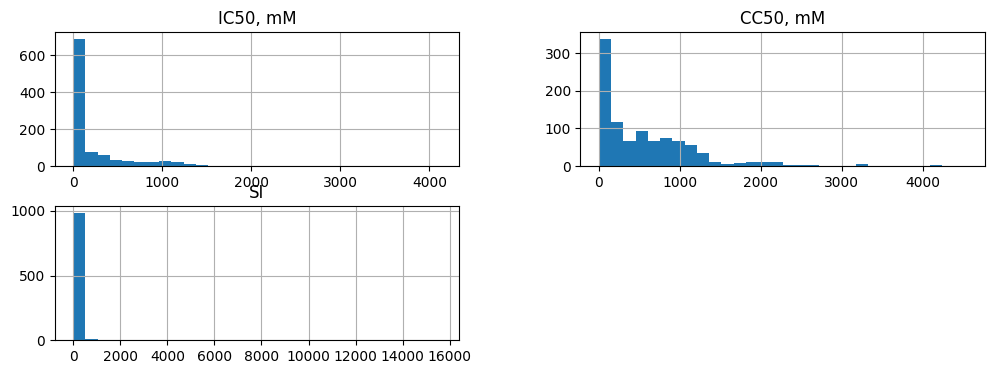

In [11]:
plt.style.use('default')
df[['IC50, mM', 'CC50, mM', 'SI']].hist(bins=30, figsize=(12, 4))
plt.show()

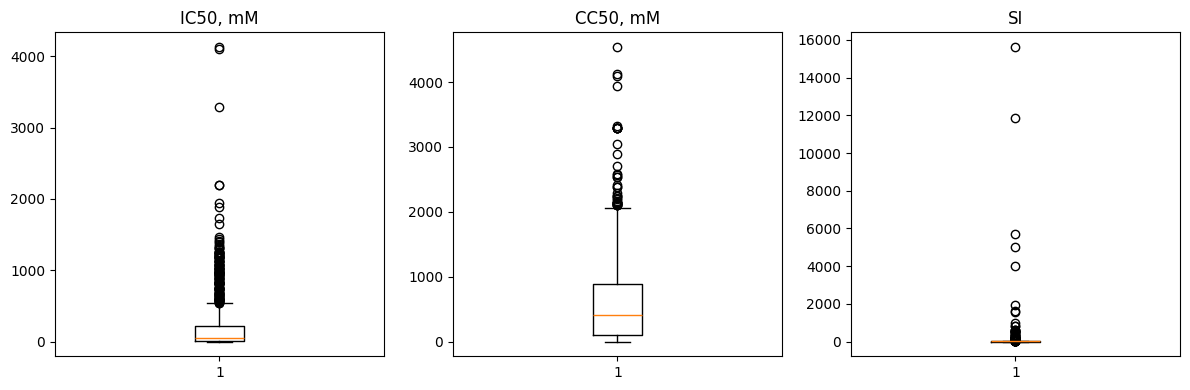

In [12]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(['IC50, mM', 'CC50, mM', 'SI'], 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Целевые признаки имеют правостороннюю асимметрию
Присутствуют значительные выбросы

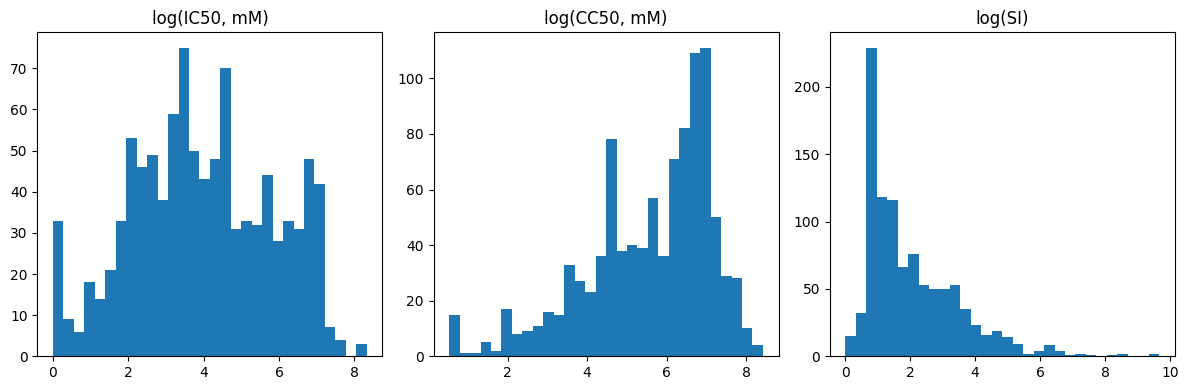

In [14]:
# Проверим лог-преобразование
plt.figure(figsize=(12, 4))

for i, col in enumerate(['IC50, mM', 'CC50, mM', 'SI'], 1):
    plt.subplot(1, 3, i)
    plt.hist(np.log1p(df[col]), bins=30)
    plt.title(f'log({col})')

plt.tight_layout()
plt.show()

С логарифмическим преобразованием асимметрия значительно сократилась. Распределения становятся ближе к нормальному

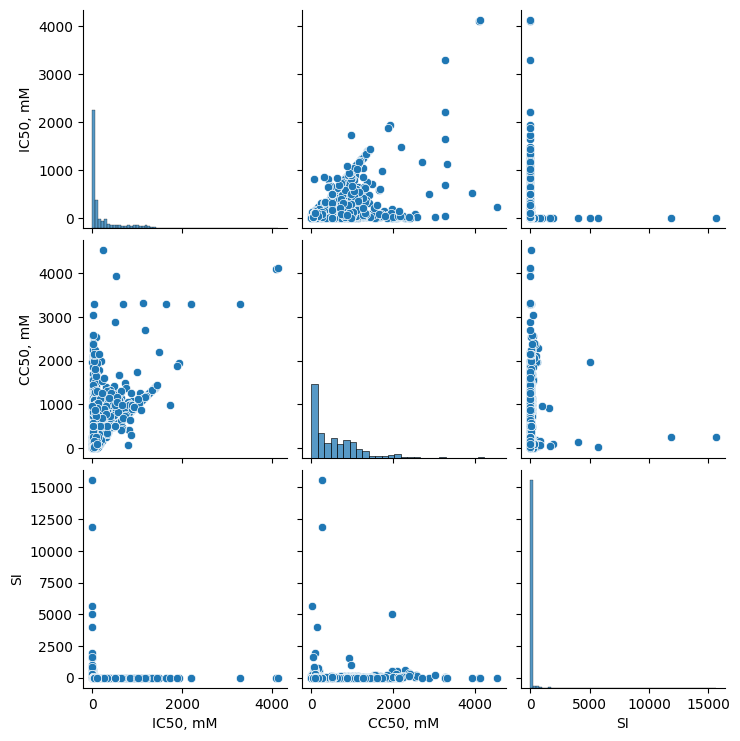

In [15]:
# Проверим связь между таргетами
sns.pairplot(df[['IC50, mM', 'CC50, mM', 'SI']])
plt.show()

- Между переменными IC50 и CC50 наблюдается слабая положительная зависимость.
- Переменная SI не демонстрирует линейной зависимости с IC50 и CC50, распределение точек сильно искажено и содержит большое количество выбросов.
Взаимосвязи между целевыми переменными носят нелинейный характер, что может усложнять задачу моделирования.

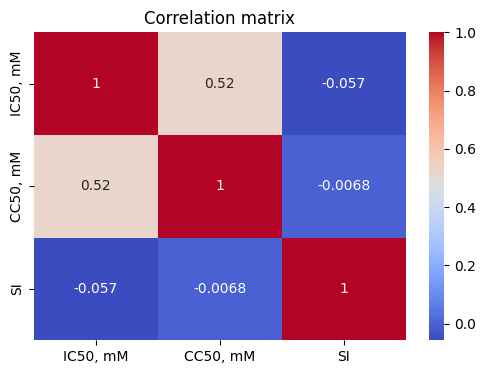

In [16]:
# Выведем матрицу корреляции целевых признаков
plt.figure(figsize=(6, 4))
sns.heatmap(df[['IC50, mM', 'CC50, mM', 'SI']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

- Между IC50 и CC50 наблюдается умеренная положительная зависимость
- Переменная SI не демонстрирует линейной зависимости с IC50 и CC50
- Вероятно, зависимость SI носит нелинейный характер

In [17]:
# Проверка зависимости SI от IC50, mM и CC50, mM
df_check = df[['IC50, mM', 'CC50, mM', 'SI']].copy()

df_check['si_formula'] = df_check['CC50, mM'] / df_check['IC50, mM']
df_check['abs_diff'] = (df_check['SI'] - df_check['si_formula']).abs()
df_check['rel_diff'] = df_check['abs_diff'] / df_check['SI'].replace(0, np.nan)

df_check[['SI', 'si_formula', 'abs_diff', 'rel_diff']].describe()

,SI,si_formula,abs_diff,rel_diff
count,1001.000000,1001.000000,1.001000e+03,1.001000e+03
mean,72.508823,72.508823,9.032310e-15,1.502608e-16
std,684.482739,684.482739,9.159952e-14,1.651876e-16
min,0.011489,0.011489,0.000000e+00,0.000000e+00
25%,1.433333,1.433333,0.000000e+00,0.000000e+00
50%,3.846154,3.846154,4.440892e-16,1.370755e-16
75%,16.566667,16.566667,1.776357e-15,2.273737e-16
max,15620.600000,15620.600000,1.818989e-12,8.463040e-16


In [18]:
(df_check['abs_diff'] < 1e-10).mean()

np.float64(1.0)

In [19]:
df_check[['SI', 'si_formula']].corr()

,SI,si_formula
SI,1.0,1.0
si_formula,1.0,1.0


- SI — производный признак(SI = CC50 / IC50)
- использовать SI совместно с CC50 и IC50 нельзя

#### Проверка датасета на наличие пропусков

In [24]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_percent = round((missing / len(df)) * 100, 2)
missing_df = pd.DataFrame({
    'Кол-во пропусков': missing,
    'Процент пропусков': missing_percent
})
missing_df

,Кол-во пропусков,Процент пропусков
MinAbsPartialCharge,3,0.3
BCUT2D_LOGPHI,3,0.3
BCUT2D_MWHI,3,0.3
MaxAbsPartialCharge,3,0.3
MinPartialCharge,3,0.3
MaxPartialCharge,3,0.3
BCUT2D_MWLOW,3,0.3
BCUT2D_CHGHI,3,0.3
BCUT2D_CHGLO,3,0.3
BCUT2D_LOGPLOW,3,0.3


In [25]:
# Проверим сколько строк содержат пропуски
rows_with_missing = df[df.isnull().any(axis=1)]
rows_with_missing

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,78,1127.094988,1127.094988,1.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,...,0,0,0,0,0,0,0,0,0,0
79,79,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,...,0,0,0,0,0,0,0,0,0,0
80,80,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,...,1,0,0,0,0,0,0,0,0,0


1) В датасете присутствуют пропуски в 12 признаках
2) Пропуски затрагивают только 3 строки (0.3% выборки)

Строки с пропусками необходимо удалить

#### Исследование признаков

In [26]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
df_features = df.drop(columns=targets)

In [27]:
# ищем константные признаки
nunique = df_features.nunique()

constant_features = nunique[nunique == 1]
constant_features

NumRadicalElectrons    1
SMR_VSA8               1
SlogP_VSA9             1
fr_N_O                 1
fr_SH                  1
fr_azide               1
fr_barbitur            1
fr_benzodiazepine      1
fr_diazo               1
fr_dihydropyridine     1
fr_isocyan             1
fr_isothiocyan         1
fr_lactam              1
fr_nitroso             1
fr_phos_acid           1
fr_phos_ester          1
fr_prisulfonamd        1
fr_thiocyan            1
dtype: int64

Константные признаки бесполезны для построения моделей. Удалить их

#### Поиск признаков с низкой вариативностью

In [28]:
df_features.nunique().describe()

count     211.000000
mean      225.772512
std       305.941911
min         1.000000
25%         3.000000
50%        19.000000
75%       415.500000
max      1001.000000
dtype: float64

In [31]:
df_features.nunique().value_counts().sort_index().head(20)

1     18
2     30
3     14
4      6
5      8
6      6
7      3
8      6
9      5
10     3
11     1
12     1
13     1
14     1
15     2
19     1
21     3
22     1
29     1
30     1
Name: count, dtype: int64

In [33]:
binary_features = df_features.columns[df_features.nunique() == 2]
df_features[binary_features].sample(5)

,fr_Al_COO,fr_Ar_COO,fr_Ar_NH,fr_COO,fr_COO2,fr_C_S,fr_HOCCN,fr_Nhpyrrole,fr_aldehyde,fr_alkyl_carbamate,...,fr_oxazole,fr_priamide,fr_pyridine,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_urea
489,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
582,0,0,1,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
59,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
599,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [34]:
low_unique_features = df_features.columns[df_features.nunique().between(3, 5)]
df_features[low_unique_features].head()

,SMR_VSA2,EState_VSA11,NumAromaticCarbocycles,fr_ArN,fr_Imine,fr_NH1,fr_NH2,fr_Ndealkylation1,fr_Ndealkylation2,fr_amide,...,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_oxime,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_quatN,fr_sulfide
0,0.0,0.0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0.0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
3,0.0,0.0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0.0,2,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- признаки с малым числом значений — нормальные
- информация в них есть
- удалять нельзя

#### Поиск выбросов в признаках

In [35]:
# Считаем выбросы через IQR
Q1 = df_features.quantile(0.25)
Q3 = df_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df_features < lower_bound) | (df_features > upper_bound)).sum()

outliers_count.sort_values(ascending=False).head(20)

VSA_EState10             250
VSA_EState9              245
fr_amide                 243
fr_Al_OH                 243
fr_aniline               222
Ipc                      218
fr_allylic_oxid          209
PEOE_VSA4                205
fr_ester                 199
PEOE_VSA13               185
fr_Al_OH_noTert          182
PEOE_VSA5                166
fr_methoxy               154
fr_ketone                154
BCUT2D_MRHI              153
fr_para_hydroxylation    147
fr_aryl_methyl           144
SMR_VSA9                 141
fr_halogen               140
fr_Imine                 137
dtype: int64

In [36]:
outliers_percent = outliers_count / len(df_features) * 100
outliers_percent.sort_values(ascending=False).head(20)

VSA_EState10             24.975025
VSA_EState9              24.475524
fr_amide                 24.275724
fr_Al_OH                 24.275724
fr_aniline               22.177822
Ipc                      21.778222
fr_allylic_oxid          20.879121
PEOE_VSA4                20.479520
fr_ester                 19.880120
PEOE_VSA13               18.481518
fr_Al_OH_noTert          18.181818
PEOE_VSA5                16.583417
fr_methoxy               15.384615
fr_ketone                15.384615
BCUT2D_MRHI              15.284715
fr_para_hydroxylation    14.685315
fr_aryl_methyl           14.385614
SMR_VSA9                 14.085914
fr_halogen               13.986014
fr_Imine                 13.686314
dtype: float64

#### Проверка корреляций между признаками

In [38]:
corr_matrix = df_features.corr()
# Берем верхний треугольник
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [39]:
# Смотрим пары с высокой корреляцией:
high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, col]) and abs(upper.loc[row, col]) > 0.9
]

len(high_corr)

154

In [40]:
high_corr[:10]

[('MaxEStateIndex', 'MaxAbsEStateIndex', np.float64(1.0)),
 ('HeavyAtomMolWt', 'MolWt', np.float64(0.9968500699143527)),
 ('ExactMolWt', 'MolWt', np.float64(0.9999985675531962)),
 ('ExactMolWt', 'HeavyAtomMolWt', np.float64(0.9968205134360122)),
 ('NumValenceElectrons', 'MolWt', np.float64(0.9812236854845559)),
 ('NumValenceElectrons', 'HeavyAtomMolWt', np.float64(0.96620144667007)),
 ('NumValenceElectrons', 'ExactMolWt', np.float64(0.9814357790361952)),
 ('MaxAbsPartialCharge', 'MinPartialCharge', np.float64(-0.9215002397470539)),
 ('MinAbsPartialCharge', 'MaxPartialCharge', np.float64(0.974736732493223)),
 ('FpDensityMorgan2', 'FpDensityMorgan1', np.float64(0.9477566410321767))]

Найдено 154 пары сильно коррелированных признака
Необходимо удалить часть признаков на основе корреляции